Function 1 dataset:
          x1        x2              y
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.605439  0.664755   7.670920e-03
11  0.628540  0.628540   2.000000e+00

Best point so far:
0.628540-0.628540
Best output so far: 2.0


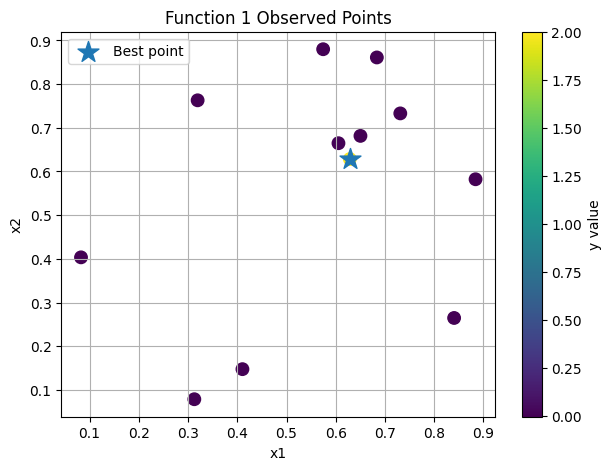

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



Fitted GP kernel:
1.01**2 * RBF(length_scale=[468, 0.0171]) + WhiteKernel(noise_level=1e-05)

Suggested next query for Function 1:
0.646922-0.622735

Model prediction:
Predicted mean: 1.9097881124398066
Predicted uncertainty: 0.17934837299576656

Submission format:
0.646922-0.622735

Top 5 candidate points:
1. 0.646922-0.622735 | mean=1.909788, std=0.179348, score=0.994635
2. 0.657785-0.622731 | mean=1.909665, std=0.179454, score=0.994635
3. 0.616527-0.622706 | mean=1.908814, std=0.180182, score=0.994623
4. 0.643730-0.622705 | mean=1.908769, std=0.180220, score=0.994622
5. 0.628170-0.622767 | mean=1.910892, std=0.178398, score=0.994620


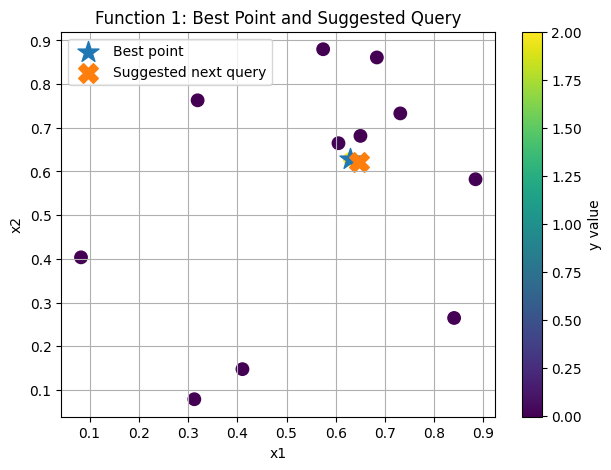

In [1]:
# Function 1 - BBO Capstone Project
# Strategy: Gaussian Process + EI/UCB + local refinement
# Function 1 is a 2D black-box function.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.stats.qmc import LatinHypercube
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel


# --------------------------------------------------
# 1. Helper functions
# --------------------------------------------------

def format_query(point, digits=6):
    """Convert a point into portal submission format: x1-x2."""
    return "-".join(f"{x:.{digits}f}" for x in point)


def clip_bounds(points):
    """Keep all values inside the portal domain [0, 1)."""
    return np.clip(points, 0.0, 0.999999)


# --------------------------------------------------
# 2. Function 1 initial data
# --------------------------------------------------

X_initial = np.array([
    [0.31940389, 0.76295937],
    [0.57432921, 0.87989810],
    [0.73102363, 0.73299988],
    [0.84035342, 0.26473161],
    [0.65011406, 0.68152635],
    [0.41043714, 0.14755430],
    [0.31269116, 0.07872278],
    [0.68341817, 0.86105746],
    [0.08250725, 0.40348751],
    [0.88388983, 0.58225397],
])

y_initial = np.array([
    1.32267704e-79,
    1.03307824e-46,
    7.71087511e-16,
    3.34177101e-124,
    -3.60606264e-03,
    -2.15924904e-54,
    -2.08909327e-91,
    2.53500115e-40,
    3.60677119e-81,
    6.22985647e-48,
])


# --------------------------------------------------
# 3. Add our iteration results
# --------------------------------------------------
# These are the results we obtained during the project.
# You can add more rows later using the same format.

X_iterations = np.array([
    [0.605439, 0.664755],   # Iteration 1
    [0.628540, 0.628540],   # Strong region found later
])

y_iterations = np.array([
    0.00767092019,          # Result of iteration 1
    2.00000000,             # Best result found
])


# Combine all data
X = np.vstack([X_initial, X_iterations])
y = np.concatenate([y_initial, y_iterations])


# --------------------------------------------------
# 4. Show current dataset
# --------------------------------------------------

df = pd.DataFrame(X, columns=["x1", "x2"])
df["y"] = y

print("Function 1 dataset:")
print(df)

best_index = np.argmax(y)
best_point = X[best_index]
best_y = y[best_index]

print("\nBest point so far:")
print(format_query(best_point))
print("Best output so far:", best_y)


# --------------------------------------------------
# 5. Visualize observations
# --------------------------------------------------

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, s=80)
plt.colorbar(scatter, label="y value")
plt.scatter(best_point[0], best_point[1], marker="*", s=250, label="Best point")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Function 1 Observed Points")
plt.legend()
plt.grid(True)
plt.show()


# --------------------------------------------------
# 6. Train Gaussian Process model
# --------------------------------------------------
# Small length scale is useful because Function 1 has sharp peaks.

kernel = (
    ConstantKernel(1.0)
    * RBF(length_scale=[0.05, 0.05])
    + WhiteKernel(noise_level=1e-6)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gp.fit(X, y)

print("\nFitted GP kernel:")
print(gp.kernel_)


# --------------------------------------------------
# 7. Acquisition functions
# --------------------------------------------------

def expected_improvement(candidates, model, y_best, xi=0.01):
    """Expected Improvement acquisition function."""
    mean, std = model.predict(candidates, return_std=True)

    std = np.maximum(std, 1e-12)
    improvement = mean - y_best - xi
    z = improvement / std

    ei = improvement * norm.cdf(z) + std * norm.pdf(z)
    return ei


def upper_confidence_bound(candidates, model, beta=2.0):
    """Upper Confidence Bound acquisition function."""
    mean, std = model.predict(candidates, return_std=True)
    return mean + beta * std


# --------------------------------------------------
# 8. Generate candidate points
# --------------------------------------------------
# Strategy:
# 70% local candidates around the best point
# 30% global candidates across the full search space

np.random.seed(42)

# Local exploitation around best point
local_candidates = best_point + np.random.normal(
    loc=0.0,
    scale=0.02,
    size=(3500, 2)
)

local_candidates = clip_bounds(local_candidates)

# Global exploration using Latin Hypercube
lhs = LatinHypercube(d=2, seed=42)
global_candidates = lhs.random(n=1500)

# Combine both
candidates = np.vstack([local_candidates, global_candidates])


# --------------------------------------------------
# 9. Calculate EI and UCB
# --------------------------------------------------

ei_scores = expected_improvement(
    candidates=candidates,
    model=gp,
    y_best=best_y,
    xi=0.001
)

ucb_scores = upper_confidence_bound(
    candidates=candidates,
    model=gp,
    beta=2.0
)


# Normalize scores before combining
ei_norm = (ei_scores - ei_scores.min()) / (ei_scores.max() - ei_scores.min() + 1e-12)
ucb_norm = (ucb_scores - ucb_scores.min()) / (ucb_scores.max() - ucb_scores.min() + 1e-12)

# Hybrid score based on our strategy
# EI = exploitation, UCB = exploration
hybrid_score = 0.70 * ei_norm + 0.30 * ucb_norm


# --------------------------------------------------
# 10. Select next query
# --------------------------------------------------

next_index = np.argmax(hybrid_score)
next_query = candidates[next_index]

pred_mean, pred_std = gp.predict(
    next_query.reshape(1, -1),
    return_std=True
)


# --------------------------------------------------
# 11. Print final result
# --------------------------------------------------

print("\nSuggested next query for Function 1:")
print(format_query(next_query))

print("\nModel prediction:")
print("Predicted mean:", pred_mean[0])
print("Predicted uncertainty:", pred_std[0])

print("\nSubmission format:")
print(format_query(next_query))


# --------------------------------------------------
# 12. Show top 5 candidates
# --------------------------------------------------

top_indices = np.argsort(hybrid_score)[-5:][::-1]

print("\nTop 5 candidate points:")

for rank, idx in enumerate(top_indices, start=1):
    point = candidates[idx]
    mean_i, std_i = gp.predict(point.reshape(1, -1), return_std=True)

    print(
        f"{rank}. {format_query(point)} | "
        f"mean={mean_i[0]:.6f}, "
        f"std={std_i[0]:.6f}, "
        f"score={hybrid_score[idx]:.6f}"
    )


# --------------------------------------------------
# 13. Plot suggested query
# --------------------------------------------------

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, s=80)
plt.colorbar(scatter, label="y value")

plt.scatter(
    best_point[0],
    best_point[1],
    marker="*",
    s=250,
    label="Best point"
)

plt.scatter(
    next_query[0],
    next_query[1],
    marker="X",
    s=200,
    label="Suggested next query"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Function 1: Best Point and Suggested Query")
plt.legend()
plt.grid(True)
plt.show()